In [1]:
import logging

import shap

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)
shap.initjs()

In [5]:
from darts.datasets import AirPassengersDataset
from darts.explainability.shap_explainer import ShapExplainer
from darts.models import LinearRegressionModel
from darts.utils.timeseries_generation import linear_timeseries

series = AirPassengersDataset().load()
future_covariates = linear_timeseries(
    start=series.start_time(),
    length=len(series) + 3,
    freq=series.freq_str,
)
model = LinearRegressionModel(
    lags=12,
    lags_future_covariates=[0, 1, 2],
    add_encoders={"cyclic": {"future": ["month"]}},
    output_chunk_length=3,
)
model.fit(series[:-36])
shap_explain = ShapExplainer(model)
results = shap_explain.explain()
results.get_explanation(horizon=1)

/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)
INFO:darts.explainability.shap_explainer:The shap method used is of type: <class 'shap.explainers._linear.LinearExplainer'>
/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


,#Passengers_target_lag-12,#Passengers_target_lag-11,#Passengers_target_lag-10,#Passengers_target_lag-9,#Passengers_target_lag-8,...,darts_enc_fc_cyc_month_cos_futcov_lag0,darts_enc_fc_cyc_month_sin_futcov_lag1,darts_enc_fc_cyc_month_cos_futcov_lag1,darts_enc_fc_cyc_month_sin_futcov_lag2,darts_enc_fc_cyc_month_cos_futcov_lag2
1950-01-01,-62.510847,-27.732848,21.145981,-15.403479,21.239482,...,-1.087206,0.807020,-1.930593,0.281600,-1.405174
1950-02-01,-58.764580,-23.680391,21.902920,-16.791879,18.223278,...,-0.943635,1.404153,-1.132913,0.324898,-0.053659
1950-03-01,-50.023291,-24.548775,23.921424,-14.362180,15.422518,...,-0.551390,1.622719,-0.043262,0.281600,1.297856
1950-04-01,-51.896424,-26.864464,20.389041,-12.106031,15.422518,...,-0.015573,1.404153,1.046389,0.163309,2.287233
1950-05-01,-56.891447,-22.812007,17.108972,-12.106031,18.007835,...,0.520243,0.807020,1.844069,0.001719,2.649371
...,...,...,...,...,...,...,...,...,...,...,...
1957-06-01,101.076140,57.658210,-47.735481,23.818804,-18.617493,...,0.912488,-0.008678,2.136041,-0.159871,2.287233
1957-07-01,125.426875,55.342521,-35.119829,15.314858,-11.076985,...,1.056060,-0.824376,1.844069,-0.278162,1.297856
1957-08-01,120.431853,40.869460,-22.756489,9.240610,-18.617493,...,0.912488,-1.421508,1.046389,-0.321460,-0.053659
1957-09-01,89.212962,26.685860,-13.925533,15.314858,-20.556481,...,0.520243,-1.640074,-0.043262,-0.278162,-1.405174


In [6]:
series[:-36]

,#Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
...,...
1957-08-01,467.0
1957-09-01,404.0
1957-10-01,347.0


In [8]:
model.predict(n=3, series=series[:-36])

,#Passengers
Month,
1958-01-01,356.926707
1958-02-01,343.253920
1958-03-01,395.569227


In [9]:
results2 = shap_explain.explain(series[:-36])
results2.get_explanation(horizon=1)

/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


,#Passengers_target_lag-12,#Passengers_target_lag-11,#Passengers_target_lag-10,#Passengers_target_lag-9,#Passengers_target_lag-8,...,darts_enc_fc_cyc_month_cos_futcov_lag0,darts_enc_fc_cyc_month_sin_futcov_lag1,darts_enc_fc_cyc_month_cos_futcov_lag1,darts_enc_fc_cyc_month_sin_futcov_lag2,darts_enc_fc_cyc_month_cos_futcov_lag2
1950-01-01,-62.510847,-27.732848,21.145981,-15.403479,21.239482,...,-1.087206,0.807020,-1.930593,0.281600,-1.405174
1950-02-01,-58.764580,-23.680391,21.902920,-16.791879,18.223278,...,-0.943635,1.404153,-1.132913,0.324898,-0.053659
1950-03-01,-50.023291,-24.548775,23.921424,-14.362180,15.422518,...,-0.551390,1.622719,-0.043262,0.281600,1.297856
1950-04-01,-51.896424,-26.864464,20.389041,-12.106031,15.422518,...,-0.015573,1.404153,1.046389,0.163309,2.287233
1950-05-01,-56.891447,-22.812007,17.108972,-12.106031,18.007835,...,0.520243,0.807020,1.844069,0.001719,2.649371
...,...,...,...,...,...,...,...,...,...,...,...
1957-09-01,89.212962,26.685860,-13.925533,15.314858,-20.556481,...,0.520243,-1.640074,-0.043262,-0.278162,-1.405174
1957-10-01,58.618449,16.554718,-22.756489,16.876807,-17.540278,...,-0.015573,-1.421508,-1.132913,-0.159871,-2.394551
1957-11-01,36.765226,26.685860,-25.027307,14.447108,-29.389649,...,-0.551390,-0.824376,-1.930593,0.001719,-2.756688
1957-12-01,58.618449,29.291011,-21.494924,23.992354,-27.666104,...,-0.943635,-0.008678,-2.222565,0.163309,-2.394551


In [4]:
series[:-36]

,#Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
...,...
1957-08-01,467.0
1957-09-01,404.0
1957-10-01,347.0


In [5]:
results

In [6]:
results.feature_values[1]["#Passengers"]

,#Passengers_target_lag-12,#Passengers_target_lag-11,#Passengers_target_lag-10,#Passengers_target_lag-9,#Passengers_target_lag-8,...,darts_enc_fc_cyc_month_cos_futcov_lag0,darts_enc_fc_cyc_month_sin_futcov_lag1,darts_enc_fc_cyc_month_cos_futcov_lag1,darts_enc_fc_cyc_month_sin_futcov_lag2,darts_enc_fc_cyc_month_cos_futcov_lag2
1950-01-01,112.0,118.0,132.0,129.0,121.0,...,1.000000e+00,0.500000,8.660254e-01,8.660254e-01,5.000000e-01
1950-02-01,118.0,132.0,129.0,121.0,135.0,...,8.660254e-01,0.866025,5.000000e-01,1.000000e+00,6.123234e-17
1950-03-01,132.0,129.0,121.0,135.0,148.0,...,5.000000e-01,1.000000,6.123234e-17,8.660254e-01,-5.000000e-01
1950-04-01,129.0,121.0,135.0,148.0,148.0,...,6.123234e-17,0.866025,-5.000000e-01,5.000000e-01,-8.660254e-01
1950-05-01,121.0,135.0,148.0,148.0,136.0,...,-5.000000e-01,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
1960-09-01,463.0,407.0,362.0,405.0,417.0,...,-5.000000e-01,-1.000000,-1.836970e-16,-8.660254e-01,5.000000e-01
1960-10-01,407.0,362.0,405.0,417.0,391.0,...,-1.836970e-16,-0.866025,5.000000e-01,-5.000000e-01,8.660254e-01
1960-11-01,362.0,405.0,417.0,391.0,419.0,...,5.000000e-01,-0.500000,8.660254e-01,0.000000e+00,1.000000e+00
1960-12-01,405.0,417.0,391.0,419.0,461.0,...,8.660254e-01,0.000000,1.000000e+00,5.000000e-01,8.660254e-01


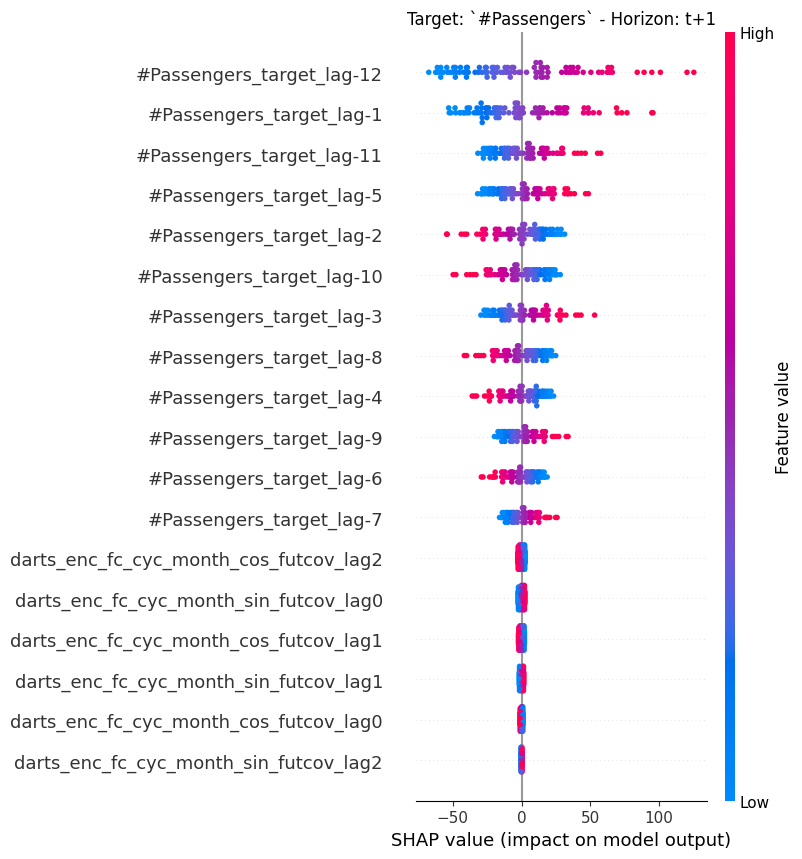

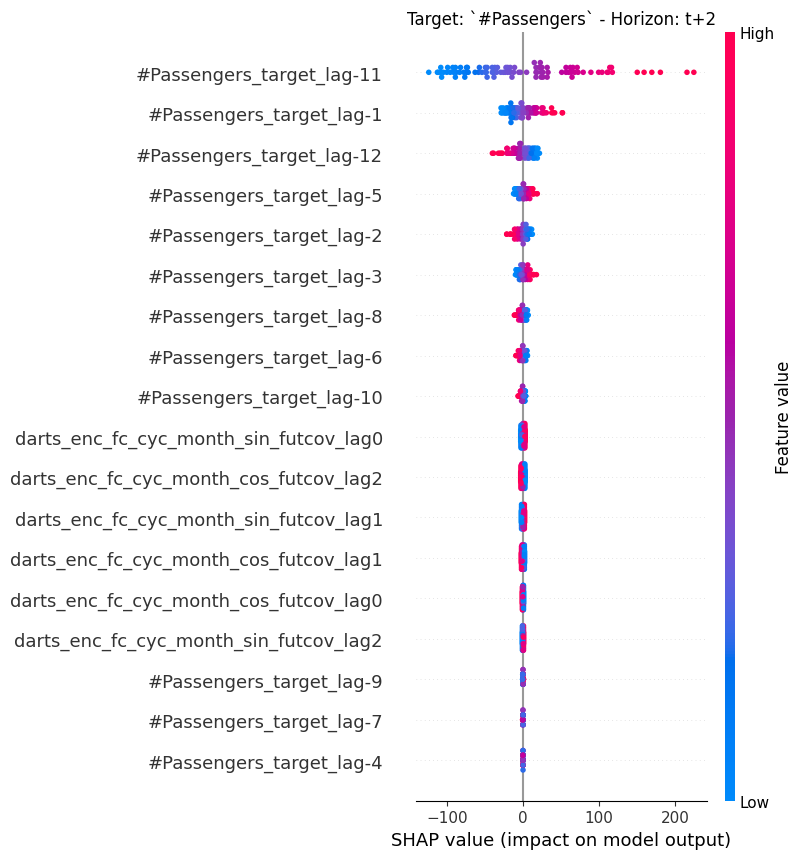

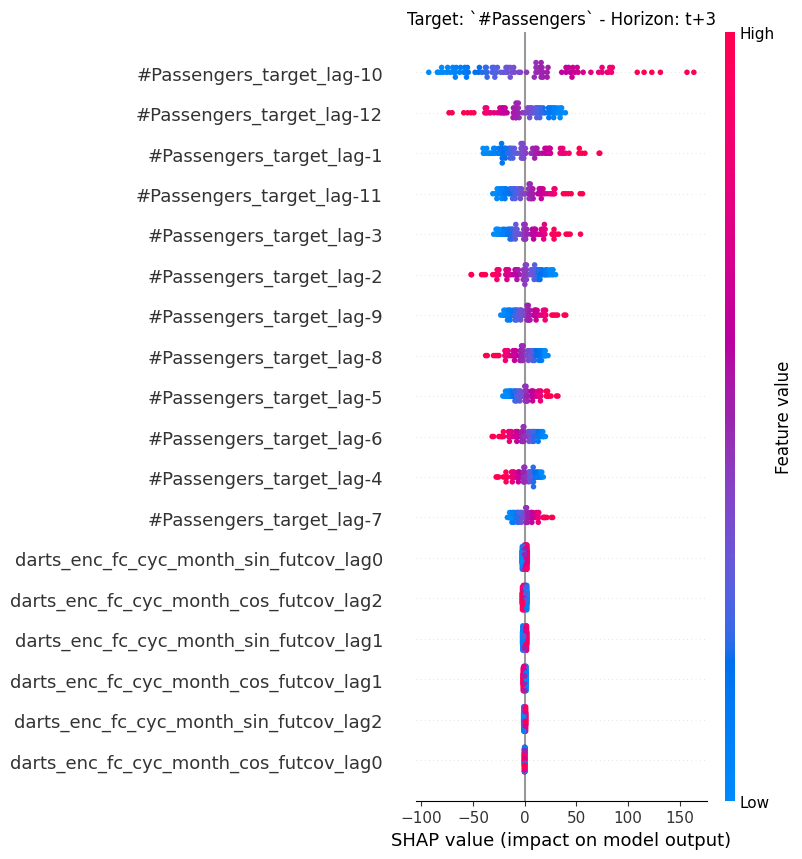

In [7]:
shap_explain.summary_plot();

In [8]:
shap_explain.force_plot_from_ts()

/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


In [9]:
from darts.utils.statistics import stationarity_tests

stationarity_tests(series[-36:])

np.False_

In [10]:
from darts.explainability.utils import _test_stationarity

_test_stationarity([series[-36:]])

False

In [11]:
import numpy as np

all([np.False_, np.False_])

False